# Pricing American options using the binomial method

The binomial method provides a general framework for pricing options under a wide range of models. It is particularly useful when a closed-form solution for the option price is difficult or impossible to obtain. One important example is the pricing of an American option under the Black–Scholes assumptions. In this notebook, we will explore how to do this.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

from scipy.stats import norm

# The binomial method

Suppose that we want to price a call option with 
* Initial stock price: $S_0$
* Strike: K
* Time to expiration: T
* volatility: $\sigma$
* interest rate: $r$

We break the time to expiration into $N$ time steps of length $\Delta t = T/N$ and assume the price follows a random walk: The price $S_{i+1}$ at time $i + 1$, is obtained from $S_i$ by the rule
$$
S_{i + 1} = \begin{cases}uS_i \quad \text{ with probability } p \\
                    dS_{i} \quad \text{ with probability } 1 - p.
            \end{cases}
$$
where $u = e^{\sigma \sqrt{\Delta t}}$ and $d = 1/u$. Under the risk free assumption we must have 
$$
e^{r\Delta t}S_i = \mathbb E[S_{i + 1}|S_i] = puS_i + (1 - p)dS_i,
$$
which yields
$$
p = \frac{e^{r\Delta t} - d}{u - d}.
$$
At each time step $i$, we have $i + 1$ possible states denoted $S_{i,k}$ for $0 \le k \le i$ given by 
$$
S_{i,k} = S_0u^k d^{i - k}.
$$
Let $C_{i,k}$ be the price of the European option if the price of the stock at time $i$ is equal to $S_{i,k}$. We need to find $C_{0,0}$. At each state $S_{i,k}$, we have 
$$
C_{i,k} := e^{-r\Delta t}\cdot (p C_{i+1, k + 1} + (1 - p)C_{i + 1, k}).
$$
We also know that 
$$
C_{N, k} = \max(S_{N,k} - K, 0),
$$
for all $0 \le k \le N$. Therefore, to find $C_{0,0}$ we can use the above recursion. 

# American options

The only difference between an American and European option is that american options allow for early exercise. So, at each step of the binomial method, we need to choose between exercising early or continuing to hold the option. This changes the above recursion to 
$$
C_{i,k} := \max(S_{i,k} - K, e^{-r\Delta t}\cdot (p C_{i+1, k + 1} + (1 - p)C_{i + 1, k})).
$$

The process for pricing put options is analogous. 

In [2]:
def binomial_european_call(S_0, K, T, r, sigma, n_steps = 100): 

    """Brief description of the function.

    Args:
        S_0 (numpy float vector): Spot prices
        K (float): Strike Price
        T (float): Time to expiration in years
        sigma (float): Yearly volatility 
        n_steps (int): The number of steps to break the process into 
                       for binomial estimation of the price

    Returns:
        float: Estimated price of the european call option with the given
               parameters. 

    Time complexity: O(n_steps^2)
    """
    S_0 = np.array(S_0).reshape(-1,1)
    K = np.array(K).reshape(-1, 1)
    dt = T/n_steps
    
    discount = np.exp(-r*dt)
    
    # Up and down ratios 
    
    u = np.exp(sigma * np.sqrt(dt))
    d = 1/u 
        
    # Risk free probability of going up 
    
    p = (np.exp(r*dt) - d)/(u - d)
    
    end_stock_prices = S_0 @ ((u**np.arange(0, n_steps + 1)) * (d**(n_steps - np.arange(0,n_steps + 1)))).reshape(1,-1)

    #initialize the values of the options at expiration date.
    values = np.maximum(end_stock_prices - K, 0)
    
    # work backwards inductively to predict the price at times T - (i + 1)*dt
    for i in range(0, n_steps): 
        values = discount * (p * values[:, 1:] + (1 - p) * values[:, :-1])
        
    return values.flatten()

def binomial_american_call(S_0, K, T, r, sigma, n_steps = 100): 

    """Brief description of the function.
    
    Args:
        S_0 (numpy float vector): Spot prices
        K (float): Strike Price
        T (float): Time to expiration in years
        sigma (float): Yearly volatility 
        n_steps (int): The number of steps to break the process into 
                       for binomial estimation of the price

    Returns:
        float: Estimated price of the american call option with the given
               parameters. 

    Time complexity: O(n_steps^2)
    """
    S_0 = np.array(S_0).reshape(-1,1)
    K = np.array(K).reshape(-1, 1)
    dt = T/n_steps
    
    discount = np.exp(-r*dt)
    
    # Up and down ratios 
    
    u = np.exp(sigma * np.sqrt(dt))
    d = 1/u 
        
    # Risk free probability of going up 
    
    p = (np.exp(r*dt) - d)/(u - d)
    
    end_stock_prices = S_0 @ ((u**np.arange(0, n_steps + 1)) * (d**(n_steps - np.arange(0,n_steps + 1)))).reshape(1,-1)

    #initialize the values of the options at expiration date.
    values = np.maximum(end_stock_prices - K, 0)
    
    # work backwards inductively to predict the price at times T - (i + 1)*dt
    for i in range(0, n_steps): 
        
        time_step = n_steps - i - 1
        # states 
        states = S_0 @ ((u**np.arange(0, time_step + 1)) * (d**(time_step - np.arange(0,time_step + 1)))).reshape(1,-1)
        # expected returns if the option is retained for another time step
        cont_values = discount * (p * values[:, 1:] + (1 - p) * values[:, :-1])

        
        # returns if exercised
        exc_values = np.maximum(states - K, 0)

        values = np.maximum(cont_values, exc_values)
        
    return values.flatten()

def binomial_european_put(S_0, K, T, r, sigma, n_steps = 100): 

    """Brief description of the function.

    Args:
        S_0 (numpy float vector): Spot prices
        K (float): Strike Price
        T (float): Time to expiration in years
        sigma (float): Yearly volatility 
        n_steps (int): The number of steps to break the process into 
                       for binomial estimation of the price

    Returns:
        float: Estimated price of the european put option with the given
               parameters. 

    Time complexity: O(n_steps^2)
    """
    S_0 = np.array(S_0).reshape(-1,1)
    K = np.array(K).reshape(-1, 1)
    dt = T/n_steps
    
    discount = np.exp(-r*dt)
    
    # Up and down ratios 
    
    u = np.exp(sigma * np.sqrt(dt))
    d = 1/u 
        
    # Risk free probability of going up 
    
    p = (np.exp(r*dt) - d)/(u - d)

    end_stock_prices = S_0 @ ((u**np.arange(0, n_steps + 1)) * (d**(n_steps - np.arange(0,n_steps + 1)))).reshape(1,-1)
    #initialize the values of the options at expiration date.
    values = np.maximum(K - end_stock_prices, 0)
    
    # work backwards inductively to predict the price at times T - (i + 1)*dt
    for i in range(0, n_steps): 
        values = discount * (p * values[:, 1:] + (1 - p) * values[:, :-1])
        
    return values.flatten()

def binomial_american_put(S_0, K, T, r, sigma, n_steps = 100): 

    """Brief description of the function.
    
    Args:
        S_0 (numpy float vector): Spot prices
        K (float): Strike Price
        T (float): Time to expiration in years
        sigma (float): Yearly volatility 
        n_steps (int): The number of steps to break the process into 
                       for binomial estimation of the price

    Returns:
        float: Estimated price of the american put option with the given
               parameters. 

    Time complexity: O(n_steps^2)
    """
    S_0 = np.array(S_0).reshape(-1, 1)
    K = np.array(K).reshape(-1, 1)
    dt = T/n_steps
    
    discount = np.exp(-r*dt)
    
    # Up and down ratios 
    
    u = np.exp(sigma * np.sqrt(dt))
    d = 1/u 
        
    # Risk free probability of going up 
    
    p = (np.exp(r*dt) - d)/(u - d)
    
    end_stock_prices = S_0 @ ((u**np.arange(0, n_steps + 1)) * (d**(n_steps - np.arange(0,n_steps + 1)))).reshape(1,-1)

    #initialize the values of the options at expiration date.
    values = np.maximum(K - end_stock_prices, 0)
    
    # work backwards inductively to predict the price at times T - (i + 1)*dt
    for i in range(0, n_steps): 
        
        time_step = n_steps - i - 1
        # states 
        states = S_0 @ ((u**np.arange(0, time_step + 1)) * (d**(time_step - np.arange(0,time_step + 1)))).reshape(1,-1)
        # expected returns if the option is retained for another time step
        cont_values = discount * (p * values[:, 1:] + (1 - p) * values[:, :-1])

        
        # returns if exercised
        exc_values = np.maximum(K - states, 0)

        values = np.maximum(cont_values, exc_values)
        
    return values.flatten()

In [3]:
def bs_call(S,K,sigma,t,r):
    '''

    Inputs:
    S(float): spot price
    K(float): strike price
    sigma(float): volatility
    t(float): time to expiration
    r(float): risk-free interest rate

    Output:
    Black-Scholes Price of Call Option
    
    '''
    d1 = (np.log(S/K)+(r+(0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)

    call_price = S*norm.cdf(d1)-np.exp(-r*t)*K*norm.cdf(d2)

    return call_price

def bs_put(S,K,sigma,t,r):
    '''

    Inputs:
    S(float): spot price
    K(float): strike price
    sigma(float): volatility
    t(float): time to expiration
    r(float): risk-free interest rate

    Output:
    Black-Scholes Price of Put Option
    
    '''
    d1 = (np.log(S/K)+(r+(0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)

    put_price = -S*norm.cdf(-d1)+np.exp(-r*t)*K*norm.cdf(-d2)

    return put_price

Let's compare the results of the binomial method with only 10 times steps with the Black-Scholes prices. 

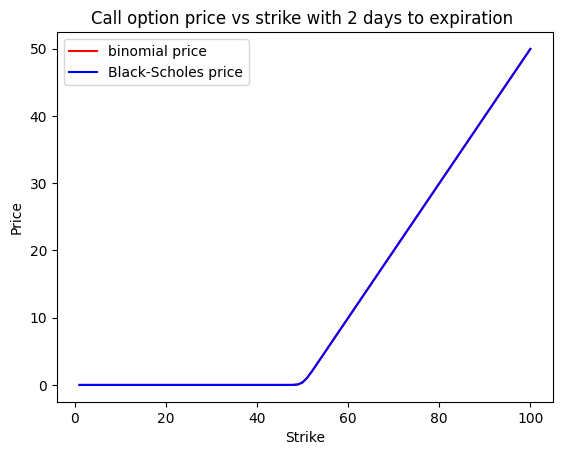

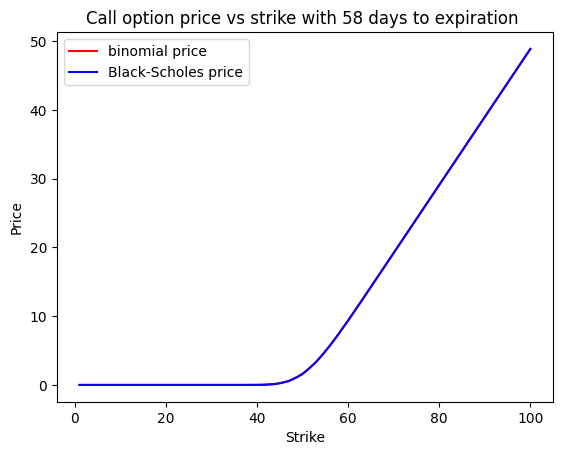

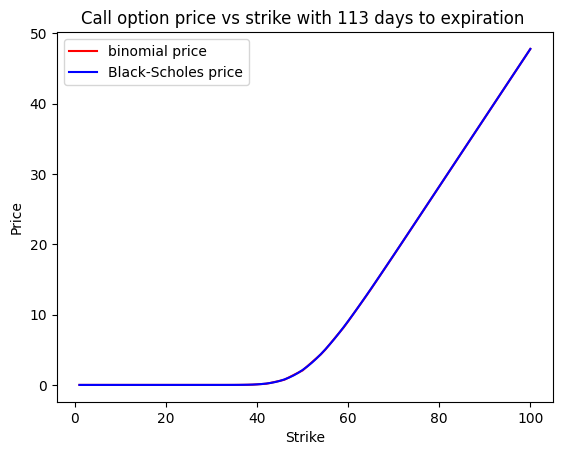

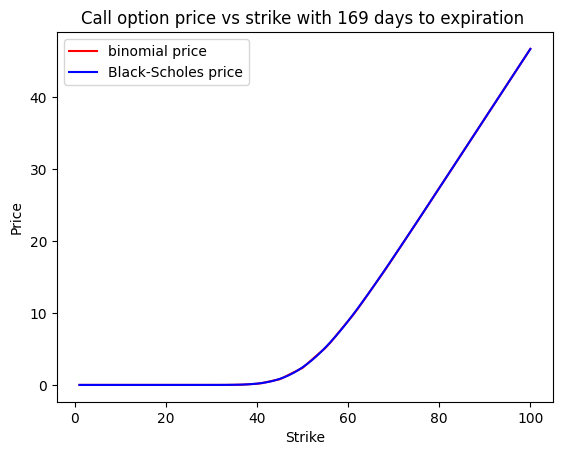

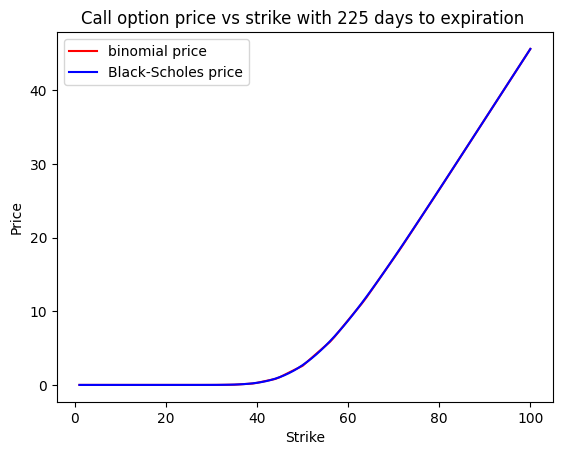

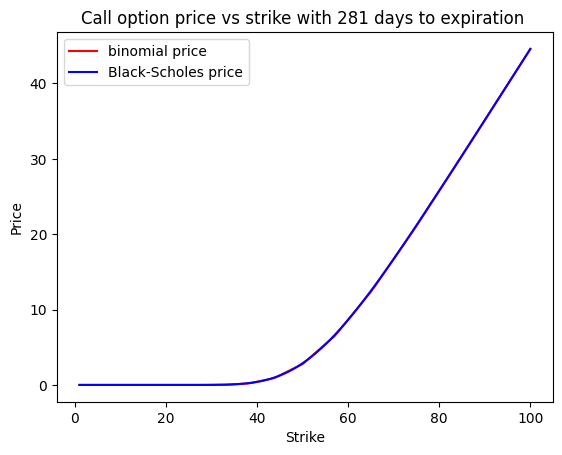

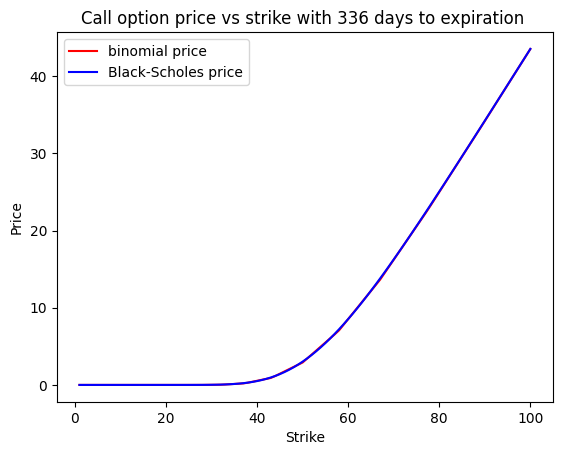

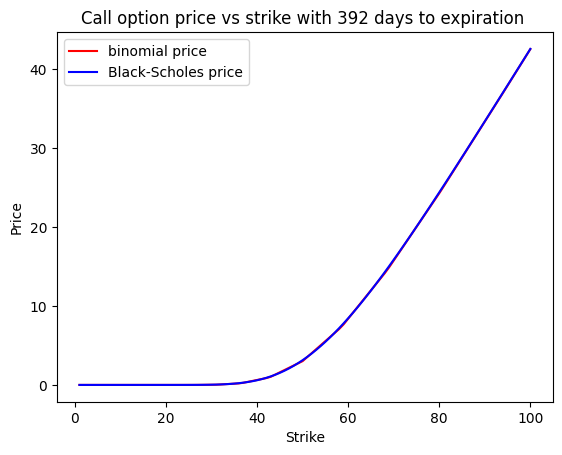

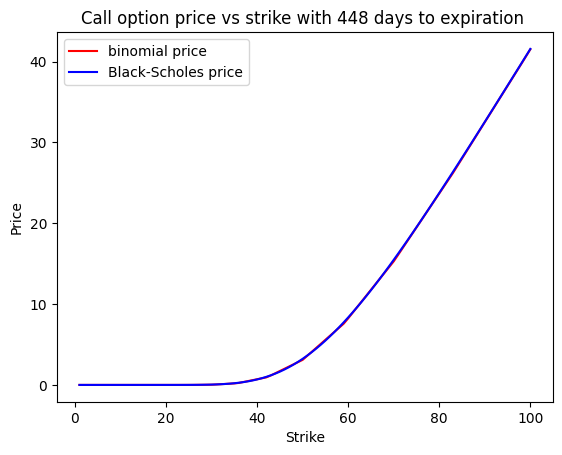

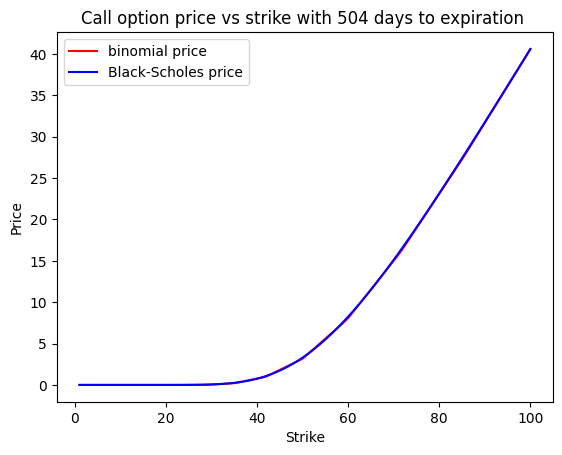

In [8]:
n = 100
num_times = 10


S_0 = 50
spots = np.array([S_0]*n)
TTEs = np.linspace(0.01, 2, num = num_times)
strikes = np.linspace(1, 100, num = n)

for tte in TTEs: 
    binomial_put_prices = binomial_european_put(S_0 = spots, K = strikes, T = tte, r = 0.05, sigma = 0.2, n_steps = 10)
    bs_put_prices = bs_put(S = spots, K = strikes, t = tte, r = 0.05, sigma = 0.2)

    plt.plot(strikes, binomial_put_prices, color = 'red', label = 'binomial price')
    plt.plot(strikes, bs_put_prices, color = 'blue', label = 'Black-Scholes price')
    plt.legend()
    plt.title(f"Call option price vs strike with {int(tte*252)} days to expiration ")    
    plt.xlabel("Strike")
    plt.ylabel("Price")
    plt.savefig('figs/european-binomial-vs-BS/price-vs-strike-tte:' + str(int(tte*252)) + '-days.jpg')
    plt.show()


Let's now compare the prices of european and american options. Naturally, we expect that american options to be worth at least as much as european ones given the possiblity to exercise early. 

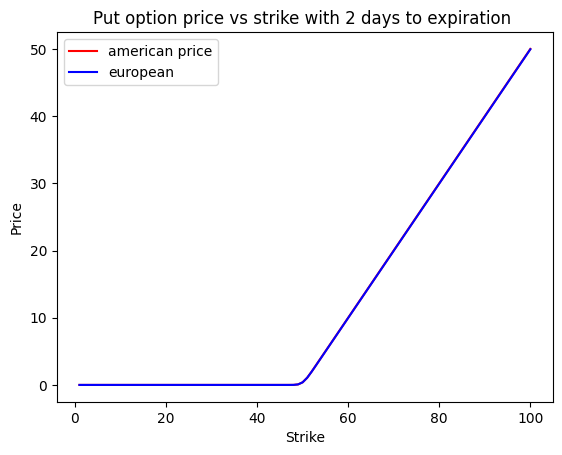

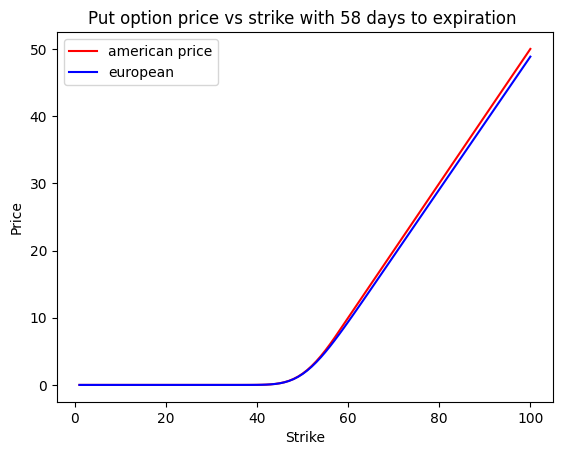

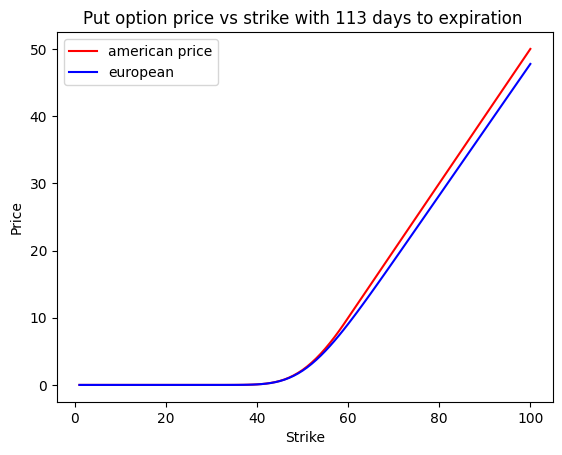

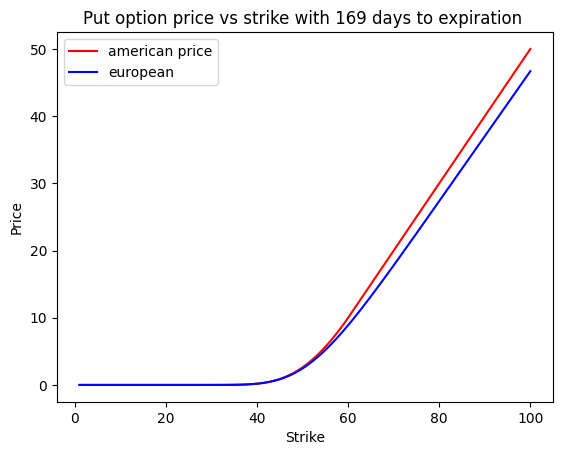

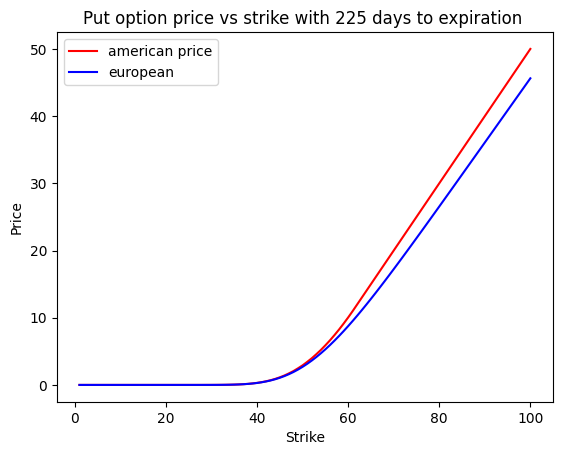

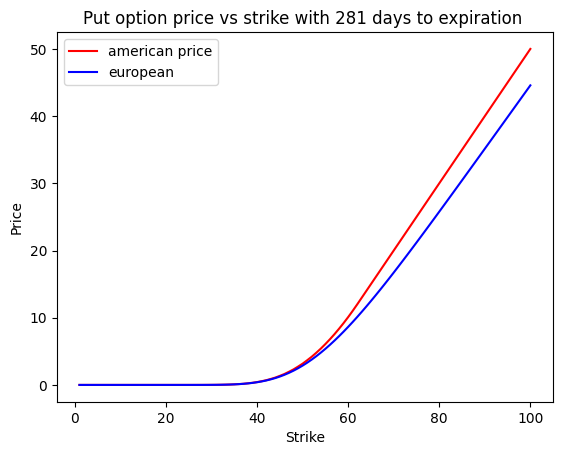

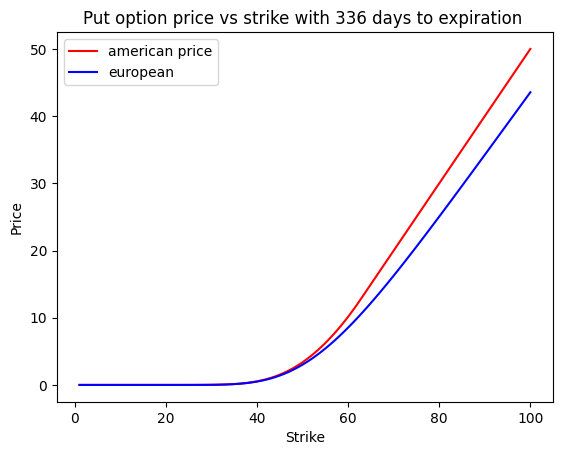

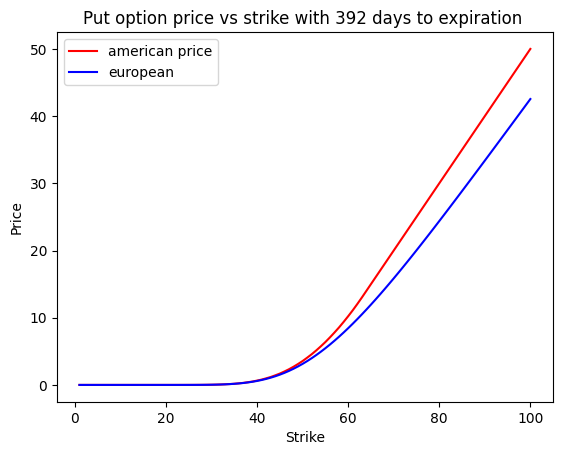

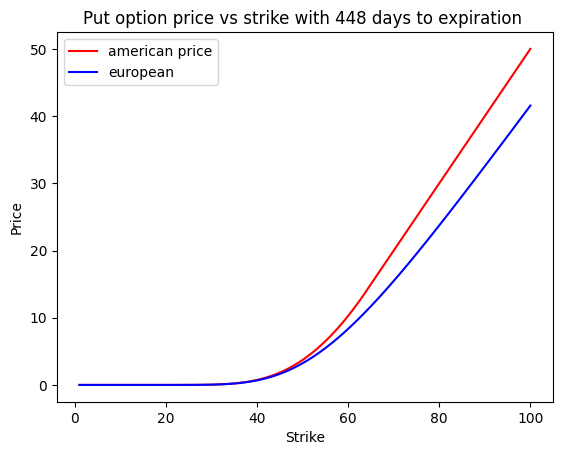

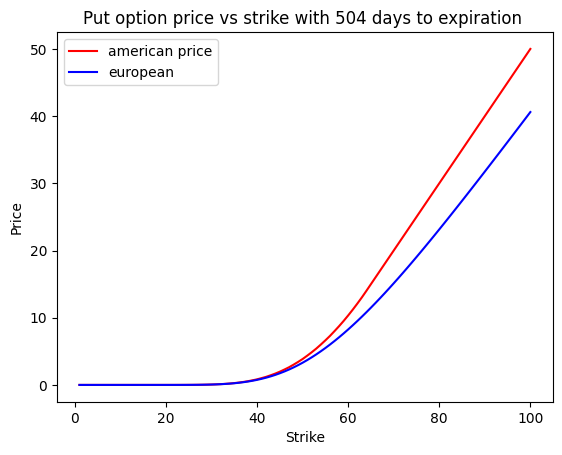

In [9]:
n = 100
num_times = 10


S_0 = 50
spots = np.array([S_0]*n)
TTEs = np.linspace(0.01, 2, num = num_times)
strikes = np.linspace(1, 100, num = n)


for tte in TTEs: 
    binomial_put_prices = binomial_american_put(S_0 = spots, K = strikes, T = tte, r = 0.05, sigma = 0.2, n_steps = 100)
    bs_put_prices = bs_put(S = spots, K = strikes, t = tte, r = 0.05, sigma = 0.2)

    plt.plot(strikes, binomial_put_prices, color = 'red', label = 'american price')
    plt.plot(strikes, bs_put_prices, color = 'blue', label = 'european')
    plt.legend()
    plt.title(f"Put option price vs strike with {int(tte*252)} days to expiration ") 
    plt.savefig('figs/american-binomial-vs-european/price-vs-strike-tte:' + str(int(tte*252)) + '-days.jpg')

    plt.xlabel("Strike")
    plt.ylabel("Price")
    plt.show()



# Longstaff-Schwartz and Monte Carlo Simulation for the price of the American option

The last thing we want to explore in this notebook is estimating the price of an American option using Monte Carlo simulation. This is more difficult to the possibility of early exercise. The Longstaff–Schwartz algorithm uses linear regression to estimate the continuation value of the option. In particular, it fits a polynomial function (quadratic in this case) of the stock price and the time remaining to maturity: 
$$
C(S, T) \approx a_0 + a_1S + a_2S^2 + a_3T + a_4T^2. 
$$
We use MSE to find the values of $a_0,\dots,a_4$. 

In [10]:
# Monte Carlo simulation for American put price

S_0 = 40
K = 50  
T = 1 
r = 0.03 
sigma = 0.2 
n_steps = 20

# Goal: Use regression to estimate the continuation value as a function of tte and current option price

dt = T/n_steps

discount = np.exp(-r*dt)

# Up and down ratios 

u = np.exp(sigma * np.sqrt(dt))
d = 1/u 
    
# Risk free probability of going up 

p = (np.exp(r*dt) - d)/(u - d)

end_stock_prices = S_0 * (u**np.arange(0, n_steps + 1)) * (d**(n_steps - np.arange(0,n_steps + 1)))

#initialize the values of the options at expiration date.
values = np.maximum(K - end_stock_prices, 0)

# A is a matrix holding the (tte, stock value, continuation value) information. To be used to train the model. 
A = np.zeros((1,5))
# work backwards inductively to predict the price at times T - (i + 1)*dt
for i in range(0, n_steps): 
    
    time_step = n_steps - i - 1
    # states 
    states = S_0 * (u**np.arange(0, time_step + 1)) * (d**(time_step - np.arange(0,time_step + 1)))
    # expected returns if the option is retained for another time step
    cont_values = discount * (p * values[1:] + (1 - p) * values[:-1])

    indices = (states <= K)
    
    time_stamps = [(i+1) * dt] * np.sum(indices)
    value_states = states[indices]
    # Add the (tte, stock value, continuation value) info to the matrix A 
    new_info = np.column_stack((time_stamps, np.pow(time_stamps, 2), value_states, np.pow(value_states, 2), cont_values[indices]))
    A = np.vstack((A, new_info))
    
    # returns if exercised
    exc_values = np.maximum(K - states, 0)

    values = np.maximum(cont_values, exc_values)



Let's look at how well our model fits the actual continuation values. 

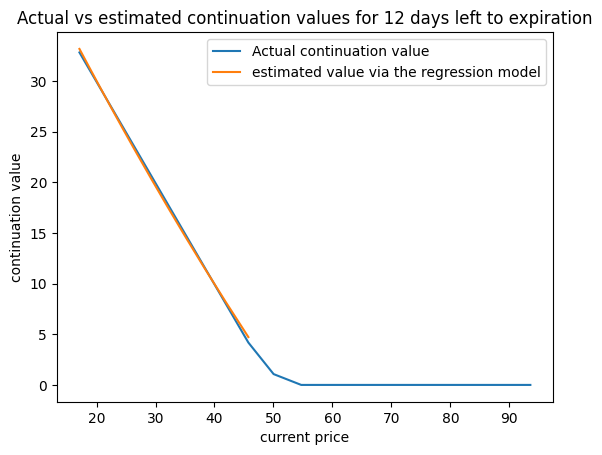

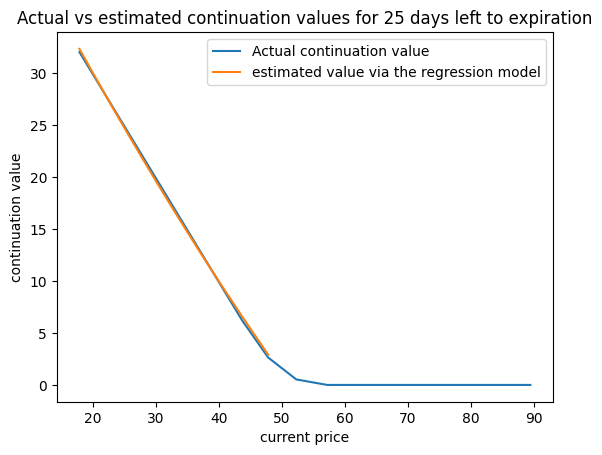

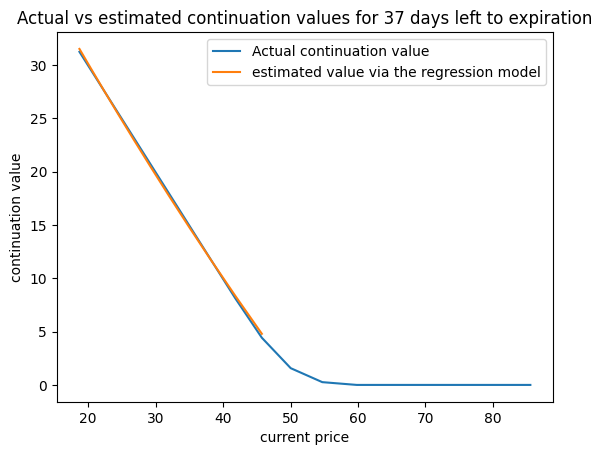

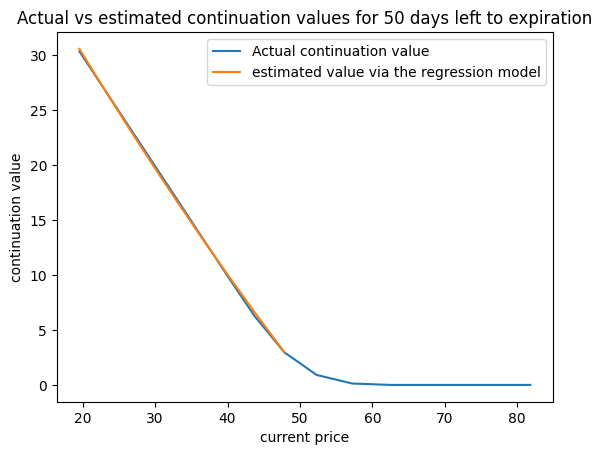

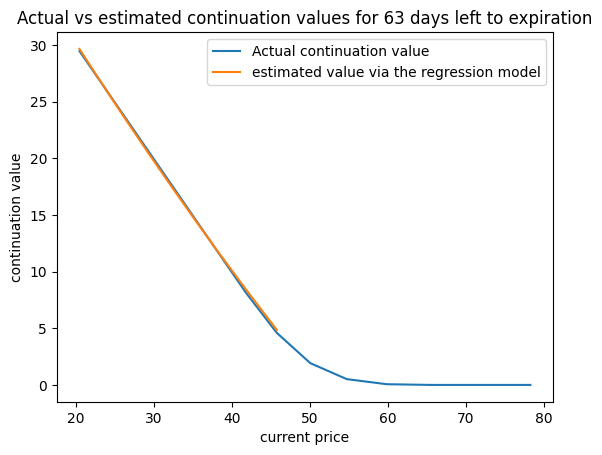

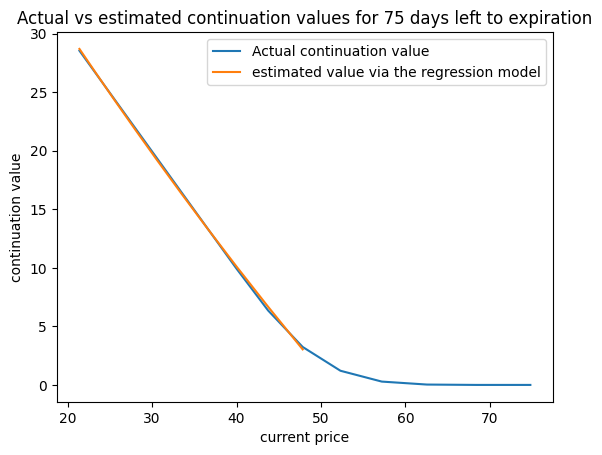

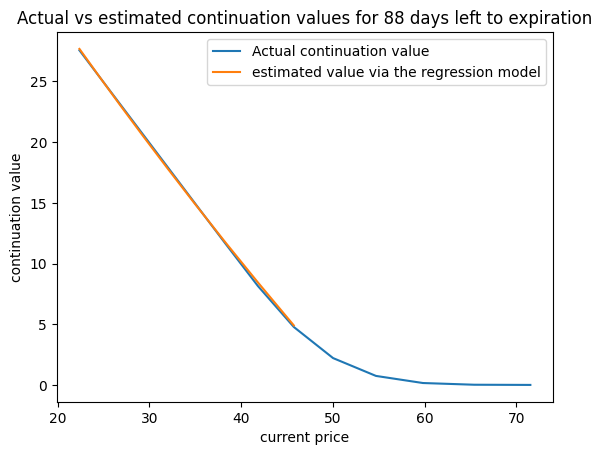

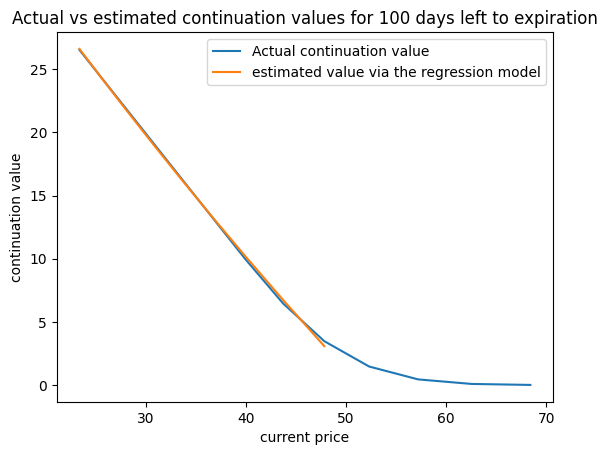

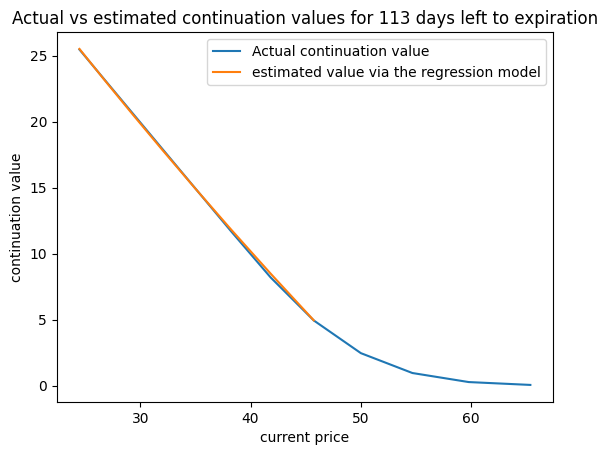

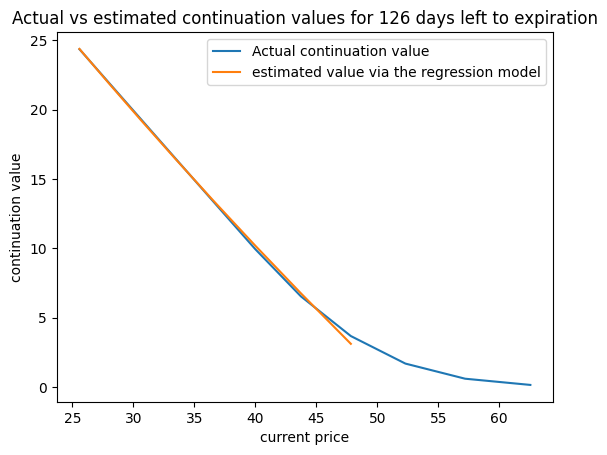

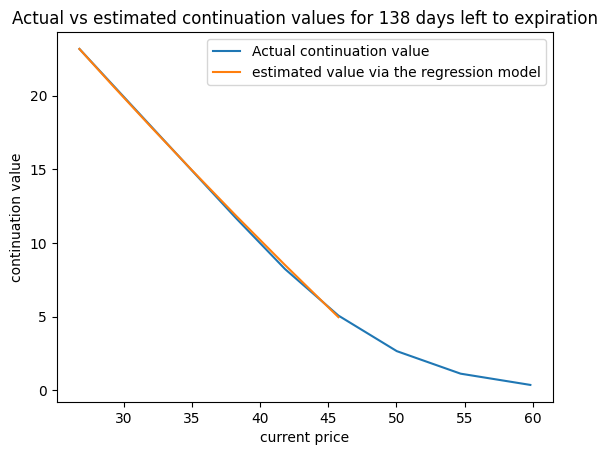

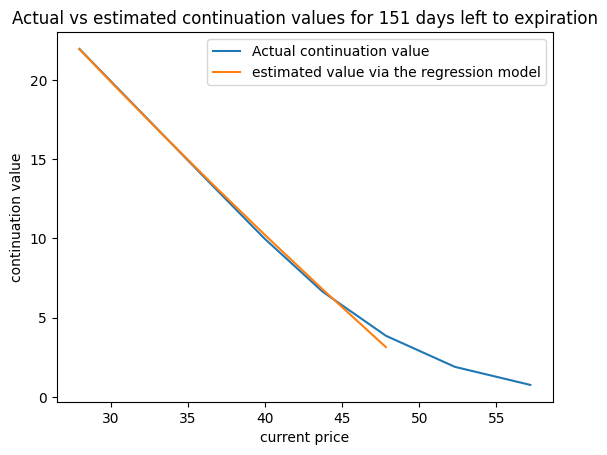

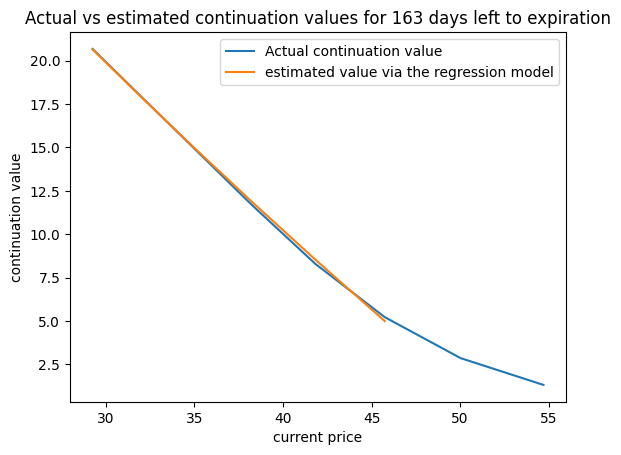

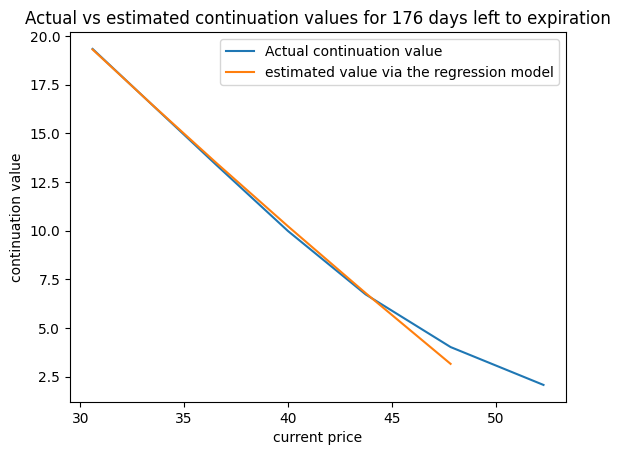

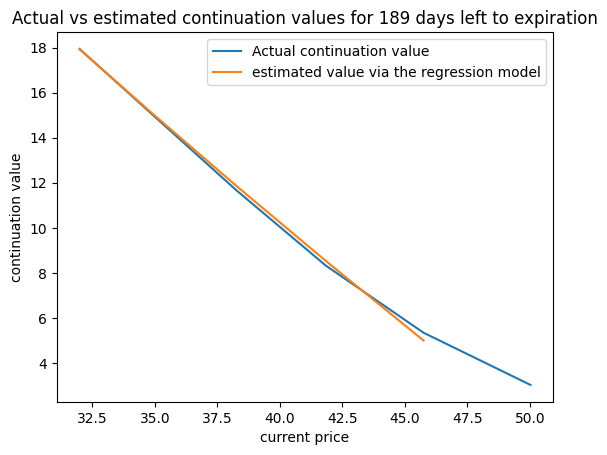

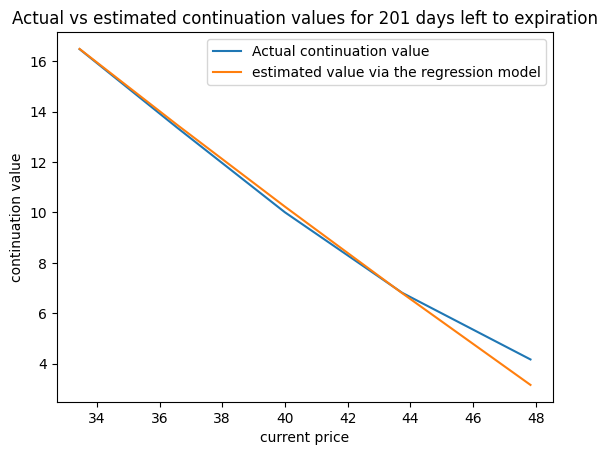

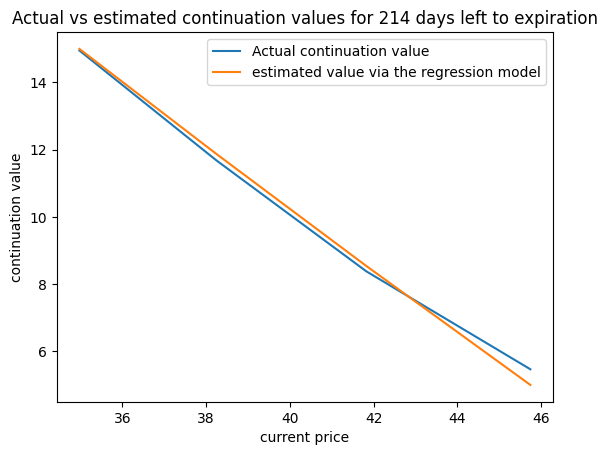

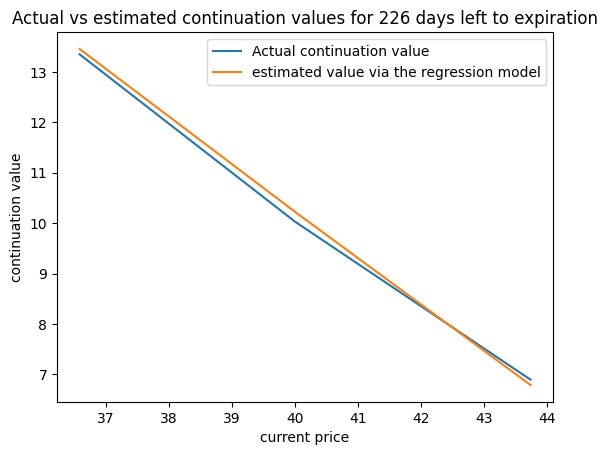

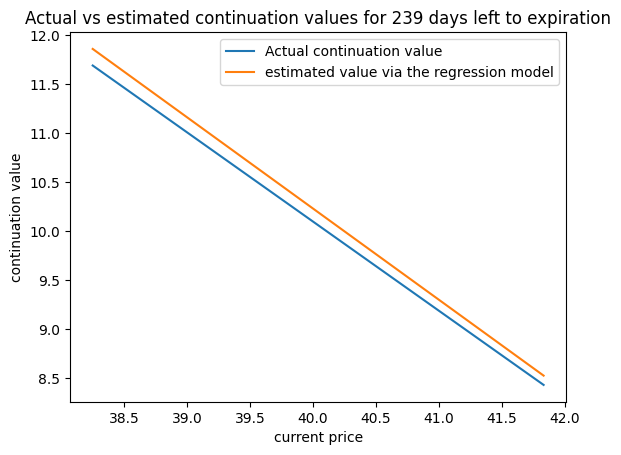

In [12]:
A = A[1:]

model = LinearRegression()
model.fit(A[:, :-1], A[:, -1].reshape(-1,1))

values = np.maximum(K - end_stock_prices, 0)

# model.predict(A[:, :-1])
for i in range(0, n_steps - 1): 
    
    time_step = n_steps - i - 1
    # states 
    states = S_0 * (u**np.arange(0, time_step + 1)) * (d**(time_step - np.arange(0,time_step + 1)))
    # expected returns if the option is retained for another time step
    cont_values = discount * (p * values[1:] + (1 - p) * values[:-1])

    indices = (states <= K)    
    tte = int((i + 1)*dt*252)
    
    time_stamps = [(i+1) * dt] * np.sum(indices)

    plt.plot(states, cont_values, label = 'Actual continuation value')
    plt.plot(states[indices], model.predict(np.column_stack((time_stamps, np.pow(time_stamps, 2), states[indices], np.pow(states[indices], 2)))), label = 'estimated value via the regression model')
    plt.legend()
    plt.xlabel('current price')
    plt.ylabel('continuation value')
    plt.title(f'Actual vs estimated continuation values for {tte} days left to expiration')
    plt.savefig('figs/Longstaff-Schwartz/estimated-cont-values/actual-vs-estimated-tte:' + str(tte) + '-days.jpg')

    plt.show()
    
    # returns if exercised
    exc_values = np.maximum(K - states, 0)

    values = np.maximum(cont_values, exc_values)

It looks ok but not great. At least we can use it for Monte Carlo Simulation! All we have to do now is to create a large number of stock paths and each step check whether it's better to continue or exercise, using our model. 

estimated option price is 10.259454660570558
binomial option price is [10.05544776]


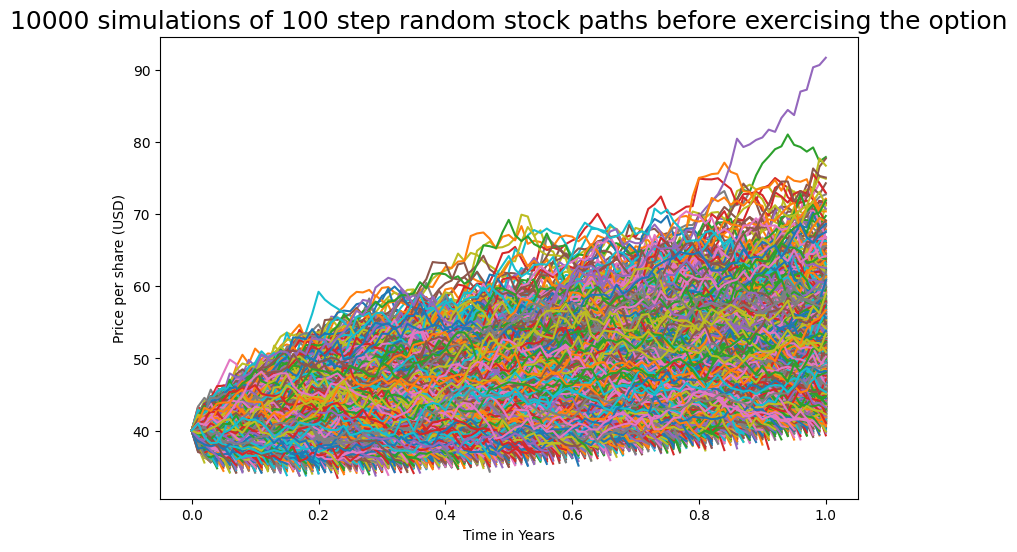

In [15]:
S0 = 40
K = 50

sigma = 0.2

t = 1

n_steps = 100

n_sims = 10000

dt = t/n_steps

r = 0.03

# Create random stock paths
noise = np.random.normal(size = (n_sims, n_steps))

log_returns = (r-sigma**2)*(0.5)*dt + sigma*np.sqrt(dt)*noise

cum_log_returns = np.cumsum(log_returns, axis = 1)

cum_log_returns = np.insert(cum_log_returns, 0, 0, axis = 1)

stock_returns = np.exp(cum_log_returns)

times = np.linspace(0,t, n_steps + 1)
plt.figure(figsize = (9,6))

option_returns = []

for stock in stock_returns:
    stock = S_0*stock
    
    # Check if early exercise happens
    
    has_value = (stock[:-1] <= K)
    exc_values = K - stock[:-1]

    X = np.column_stack((t - times[:-1], np.pow(t - times[:-1], 2), stock[:-1], np.pow(stock[:-1], 2)))

    predicted_retained_values = model.predict(X)

    indices = (exc_values >= predicted_retained_values.flatten()) & (has_value)
    
    if(np.sum(indices) != 0):
        index = np.argmax(indices)
        option_returns.append(K - stock[index])
    else:
        index = n_steps
        option_returns.append(np.maximum(K - stock[-1], 0))
    
    plt.plot(times[0:index+1], stock[0:index+1])


print(f'estimated option price is {np.mean(option_returns)}')
print(f'binomial option price is {binomial_american_put(40, 50, 1, 0.03, 0.2, n_steps = 1000)}')
plt.title(f'{n_sims} simulations of {n_steps} step random stock paths before exercising the option', size = 18)

plt.ylabel('Price per share (USD)')
plt.xlabel('Time in Years')
plt.savefig('figs/path simulations for american option pricing.png')
plt.show()

Also, our estimate for the price of a put option with current price 40, Strike 50, tte = 1 year, $\sigma = 0.2$, and $r = 0.03$ is around $10.2$ where the price using the binomial method is 10.05. This isn't perfect but is still pretty close. Also, it's really cool to see that a good number of the paths end up exercising the put option early!  